Qwen 2.5 Instruct Model: https://huggingface.co/Qwen/Qwen3.5-397B-A17B#benchmark-results:~:text=post%20Qwen3.5.-,Model%20Overview,-Type%3A%20Causal%20Language

In [ ]:
!pip -q install -U "transformers>=4.41.0" accelerate bitsandbytes sentencepiece pandas scikit-learn

import json, time
import pandas as pd
import numpy as np
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 139.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 108.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, 

Load Qwen2.5

In [ ]:
model_id = "Qwen/Qwen2.5-7B-Instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    use_fast=True,
    padding_side="left"
)

tokenizer.pad_token = tokenizer.eos_token


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config,
)

print("Loaded:", model_id)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-7B-Instruct


Load test set (kaggle)

In [ ]:
KAGGLE_CLEAN_PATH = "../kaggle_data.json"

with open(KAGGLE_CLEAN_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

X_test = [item["review_content"] for item in test_data]
y_test = [1 if item["is_positive"] else 0 for item in test_data]

print("Test samples (Kaggle):", len(X_test))
print("Pos:", sum(y_test), "Neg:", len(y_test)-sum(y_test))
print("Unique labels in y_test:", set(y_test))



Test samples (Kaggle): 117458
Pos: 55789 Neg: 61669
Unique labels in y_test: {0, 1}


In [ ]:
# Stratified Sampling:
# ensures unbiased slicing and balanced dataset
# takes exactly half pos and neg based on N size
import random
random.seed(42)

pos_idx = [i for i,y in enumerate(y_test) if y == 1]
neg_idx = [i for i,y in enumerate(y_test) if y == 0]

N = 2000  # take 2000 for now due to runtime lol
half = N // 2

idx = random.sample(pos_idx, half) + random.sample(neg_idx, N-half)
random.shuffle(idx)

X_sub = [X_test[i] for i in idx]
y_sub = [y_test[i] for i in idx]

print("Subset size:", len(X_sub))
print("Subset pos:", sum(y_sub), "neg:", len(y_sub)-sum(y_sub))
print("Unique labels:", set(y_sub))

Subset size: 2000
Subset pos: 1000 neg: 1000
Unique labels: {0, 1}


Qwen classifier with strict label output to match our custom models

In [ ]:
import re

# helps parse LM output
def extract_label_from_generation(full_text: str):
    tail = full_text.split("Return:")[-1].strip().lower()
    m = re.search(r"\b(positive|negative)\b", tail)
    if m:
        return 1 if m.group(1) == "positive" else 0
    m2 = re.search(r"\b(positive|negative)\b", full_text.lower())
    if m2:
        return 1 if m2.group(1) == "positive" else 0
    return -1

def qwen_predict_labels(texts, batch_size=4, max_new_tokens=3, max_length=512):
    preds = []
    t0 = time.time()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        prompts = []

        for txt in batch:
            messages = [
                {"role": "system", "content": "You are a classifier. Return exactly one word: Positive or Negative. No other text."},
                {"role": "user", "content": f"{txt}\n\nReturn:"}
            ]
            prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
            )

        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        for full in decoded:
            preds.append(extract_label_from_generation(full))

    t1 = time.time()
    return preds, (t1 - t0)



In [ ]:
y_pred, seconds = qwen_predict_labels(X_sub, batch_size=16)

acc = accuracy_score(y_sub, y_pred)
prec = precision_score(y_sub, y_pred, zero_division=0)
rec = recall_score(y_sub, y_pred, zero_division=0)
f1 = f1_score(y_sub, y_pred, zero_division=0)

print("="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Benchmark Model: Qwen with zero shot prompting")
print(f"Test data: Kaggle cleaned ({len(test_data):,} samples)")
print(f"\nMetrics:")
print(f"N:         {N}")
print(f"Seconds:   {seconds:.2f}  (sec/ex: {seconds/N:.4f})")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_sub, y_pred, target_names=["Negative","Positive"], zero_division=0))


RESULTS SUMMARY
Benchmark Model: Qwen with zero shot prompting
Test data: Kaggle cleaned (117,458 samples)

Metrics:
N:         2000
Seconds:   510.76  (sec/ex: 0.2554)
Accuracy:  0.8630
Precision: 0.9024
Recall:    0.8140
F1 Score:  0.8559

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.83      0.91      0.87      1000
    Positive       0.90      0.81      0.86      1000

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000




--- Confusion Matrix ---
[[912  88]
 [186 814]]


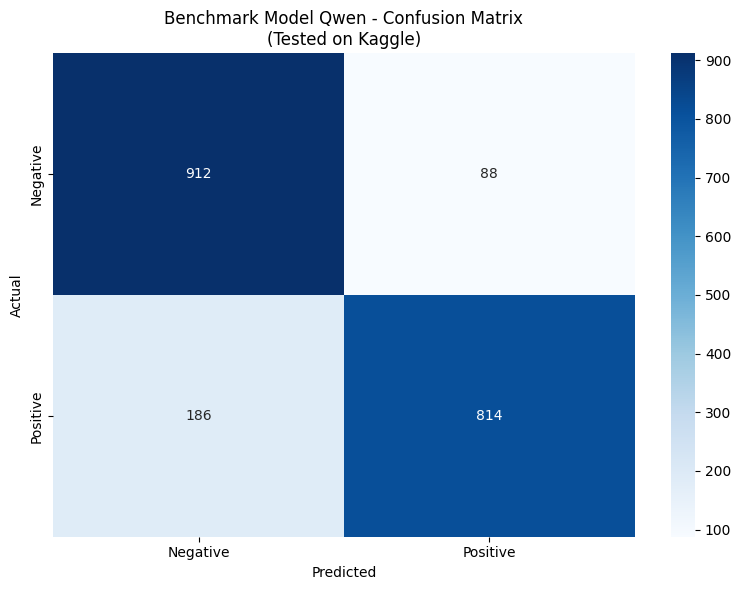

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_sub, y_pred)
print("\n--- Confusion Matrix ---")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Benchmark Model Qwen - Confusion Matrix\n(Tested on Kaggle)')
plt.tight_layout()
plt.show()